# Seq2Seq

## 정의

**Seq2Seq(Sequence-to-Sequence)** 는 가변 길이 입력 시퀀스를 가변 길이 출력 시퀀스로 변환하는 신경망 구조이다. 입력과 출력의 길이와 단어 순서가 달라도 하나의 모델로 연결할 수 있으므로, 문장을 받아 새로운 문장을 만드는 생성 문제에 사용한다.

## 필요한 이유와 사용처

문장 분류는 입력 문장 하나를 클래스 하나로 바꾸지만, 번역과 요약은 입력 문장으로부터 여러 출력 토큰을 순서대로 만들어야 한다. Seq2Seq는 입력을 읽는 **Encoder** 와 출력을 생성하는 **Decoder** 를 분리하여 기계 번역, 문서 요약, 대화 생성과 같은 작업을 처리한다.

## 핵심 작동 방식

Encoder는 입력 토큰을 순서대로 읽어 `hidden`과 `cell` 같은 문맥 상태를 만든다. Decoder는 이 상태를 초기값으로 받아 `<SOS>`에서 시작하고, 목표 문장의 토큰을 하나씩 생성하다가 `<EOS>`에서 멈춘다.

학습에서는 실제 정답의 이전 토큰을 Decoder 입력으로 주는 **Teacher Forcing** 을 사용한다. 추론에서는 정답을 알 수 없으므로 직전 모델 예측을 다음 입력으로 다시 사용하는 **자동회귀 생성**을 수행한다.

## 주요 특징과 한계

- 입력 길이와 출력 길이가 서로 달라도 처리할 수 있다.
- 입력과 출력의 언어·순서·어휘가 달라도 Encoder–Decoder 구조로 연결할 수 있다.
- 기본 Seq2Seq는 입력 전체를 마지막 `hidden`과 `cell`에 압축하므로 긴 입력에서 앞부분 정보가 약해질 수 있다.
- 추론에서는 이전 예측이 다음 입력이 되므로 한 번의 잘못된 예측이 뒤 토큰에 영향을 줄 수 있다.

## 이번 노트북에서 확인할 내용

작은 영한 병렬 데이터로 `토큰 ID → Embedding → Encoder hidden/cell → Decoder 로짓 → 손실 → 역전파 → greedy 생성`의 흐름을 확인한다. 학습 문장 재현은 계산 경로가 연결됐다는 증거이며 새로운 문장에 대한 번역 성능을 보장하지 않는다.


t## 01. Seq2Seq와 Encoder–Decoder

Seq2Seq는 **Encoder가 입력 시퀀스를 읽고 Decoder가 출력 시퀀스를 생성하는 구조**이다. 입력 전체를 먼저 문맥 상태로 만든 뒤 Decoder에 전달하므로 입력과 출력의 길이 및 단어 순서가 서로 달라도 처리할 수 있다.

- **Encoder**: 입력 토큰을 순서대로 읽고 입력 문맥을 나타내는 상태를 만드는 모듈
- **Decoder**: Encoder 상태를 초기값으로 받아 출력 토큰을 순서대로 만드는 모듈

**[ Encoder–Decoder 동작 애니메이션 (마라티어 번역 예시) ]**

입력 단어가 Encoder로 들어가고, 문맥 상태가 Decoder에 전달된 뒤 번역 토큰이 하나씩 나타나는 과정을 단순화해 보여 준다. `입력 읽기 → 문맥 전달 → 출력 생성`이라는 흐름은 현재 영한 예제와 같다.

![입력 문장을 읽은 Encoder가 문맥을 전달하고 Decoder가 번역 문장을 생성하는 애니메이션](https://d.pr/i/HR5Vt6+)

출처: [Aditya Shirsath, Neural Machine Translation Using Sequence to Sequence Model](https://medium.com/geekculture/neural-machine-translation-using-sequence-to-sequence-model-164a5905bcd7)

애니메이션은 전체 움직임만 보여 주며 `hidden`, `cell`, `<SOS>`, `<EOS>`는 생략한다. 아래 정적 그림에서 현재 코드가 실제로 전달하는 상태와 생성 시작·종료 토큰을 함께 확인한다.

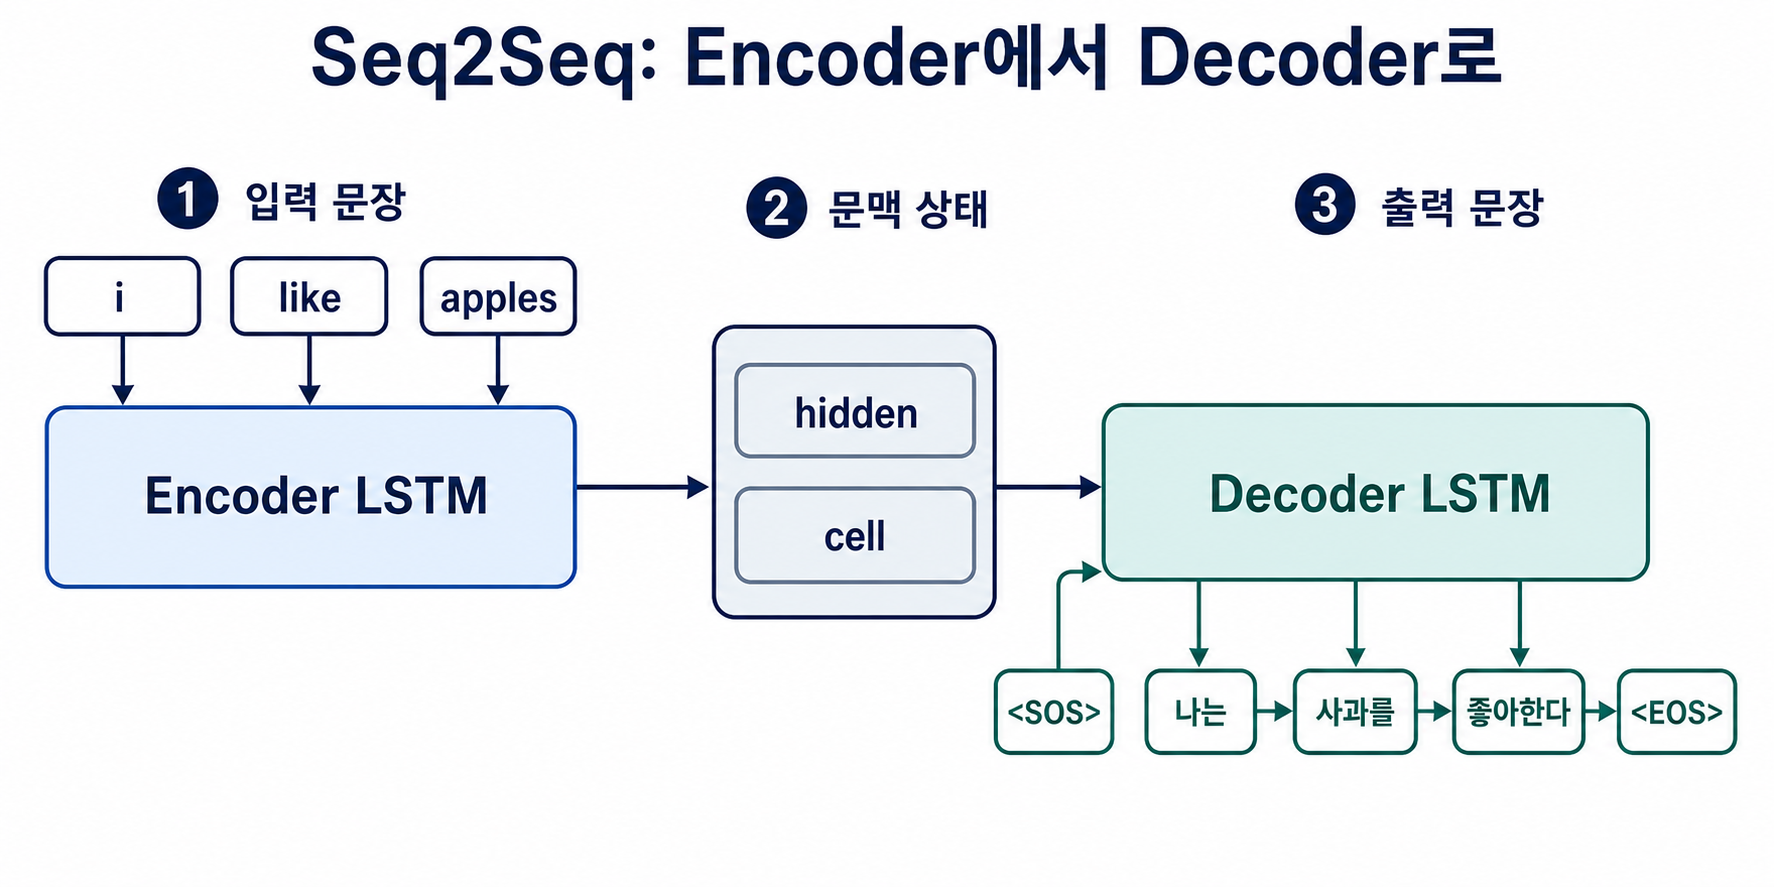

그림에서 Encoder LSTM은 `i`, `like`, `apples`를 순서대로 처리한 뒤 마지막 `hidden`과 `cell`을 Decoder LSTM에 전달한다. Decoder는 `<SOS>`를 시작 신호로 받고 `나는 → 사과를 → 좋아한다`를 차례로 생성한 뒤 `<EOS>`에서 종료한다.

`hidden`은 마지막 위치에서 밖으로 나온 요약 상태이고, `cell`은 LSTM 내부에서 장기 정보를 운반하는 기억 상태이다. 두 상태의 shape는 `(num_layers, batch_size, hidden_dim)` 순서이다.

- `num_layers`: 쌓은 LSTM 층 수
- `batch_size`: 한 번에 처리하는 문장 수
- `hidden_dim`: 문장 상태 하나를 표현하는 값의 수

현재 코드는 LSTM 한 층으로 문장 12개를 한꺼번에 처리하고 상태값을 32개 사용하므로 학습 시 `hidden`과 `cell`의 실제 shape는 `(1, 12, 32)`이다.

Decoder에 어떤 상태를 전달하는지는 학습과 추론에서 같지만 **Decoder에 넣는 토큰**은 서로 다르다. 다음 절에서는 이 차이를 이해하기 위해 특수 토큰과 Teacher Forcing을 먼저 정리한다.


## 02. 특수 토큰과 학습·추론의 Decoder 입력

Decoder는 목표 문장을 생성하기 위해 문장의 시작, 종료와 빈자리를 나타내는 특수 토큰을 사용한다.

- `<PAD>`는 길이가 다른 문장을 같은 텐서 크기로 맞추기 위한 빈자리이다.
- `<SOS>`는 Decoder에게 첫 번째 단어 생성을 시작하라고 알리는 입력이다.
- `<EOS>`는 정답 문장이 끝났다는 표시이며 추론을 멈추는 조건이다.
- `<OOV>`는 어휘에 없는 토큰을 하나의 유효한 ID로 바꾸지만 원래 단어의 의미를 보존하지는 않는다.

### Teacher Forcing

**Teacher Forcing**은 Decoder가 다음 단어를 연습할 때 **모델이 직전에 예측한 단어가 아니라 정답 문장의 직전 단어를 입력으로 주는 학습 방법**이다.

예를 들어 정답이 `나는 사과를 좋아한다`이면 Decoder는 다음 관계를 학습한다.

```text
<SOS>를 입력받아    → 나는을 예측한다.
나는을 입력받아     → 사과를을 예측한다.
사과를을 입력받아   → 좋아한다를 예측한다.
좋아한다를 입력받아 → <EOS>를 예측한다.
```

따라서 같은 정답 문장에서 다음 두 배열을 따로 만든다.

```text
Decoder에 실제로 넣는 입력:  <SOS>  나는    사과를    좋아한다
각 위치에서 맞혀야 할 정답:   나는   사과를   좋아한다  <EOS>
```

입력과 정답이 한 칸 어긋나 있는 이유는 **현재 위치에 이전 정답 토큰을 넣고 바로 다음 정답 토큰을 맞히게 하기 위해서**이다. `decoder_input_ids`만 Decoder에 들어가고, `decoder_target_ids`는 Decoder에 넣지 않는다. 정답 ID는 모델이 만든 로짓과 비교하여 손실을 계산할 때만 사용한다.

학습에서는 정답 문장을 알고 있으므로 Teacher Forcing을 사용할 수 있다. 반면 실제 번역인 추론에서는 정답이 없으므로 `<SOS>`로 시작한 뒤 모델이 방금 예측한 토큰을 다음 입력으로 다시 넣는다. 이를 **자동회귀(Autoregressive) 생성**이라고 한다.

```text
학습: <SOS> → 정답 `나는` → 정답 `사과를` → 정답 `좋아한다`
추론: <SOS> → 모델 예측 → 그 예측을 다시 입력 → 다음 모델 예측
```

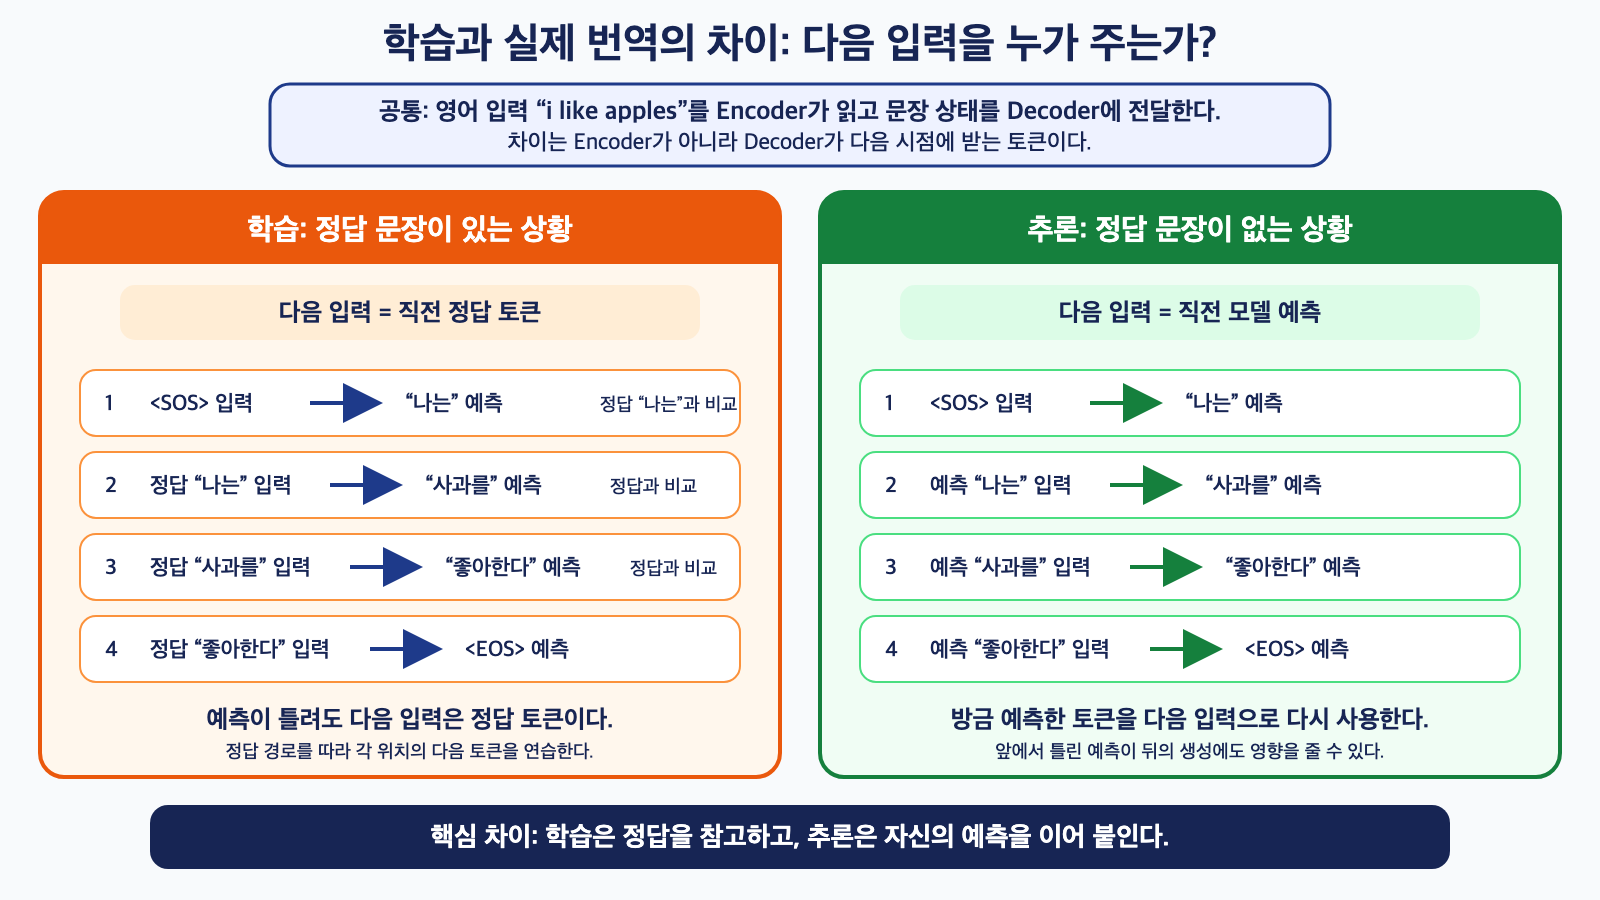

그림은 다음 순서로 읽는다.

1. 맨 위의 Encoder 과정은 학습과 추론에서 같다.
2. 왼쪽 학습은 `정답의 직전 토큰`을 다음 Decoder 입력으로 사용한다.
3. 오른쪽 추론은 `모델이 방금 예측한 토큰`을 다음 Decoder 입력으로 사용한다.
4. 따라서 학습은 정답 경로를 따라 연습하지만, 추론은 앞의 예측이 틀리면 뒤의 생성에도 영향을 받을 수 있다.

이 그림은 두 입력 방식의 차이에만 집중하기 위해 shape, loss와 역전파를 의도적으로 제외한다.


## 03. 작은 영한 병렬 데이터와 어휘 만들기

병렬 데이터는 같은 의미를 가진 입력 영어 문장과 출력 한국어 문장의 쌍이다. 여기서는 구조가 반복되는 12개 영한 문장만 사용하여 짧은 시간에 번역 학습 경로를 확인한다. 실제 번역 모델의 성능을 평가하려면 더 다양한 표현과 문맥을 가진 학습·검증·테스트 말뭉치를 분리해야 한다.

Encoder와 Decoder는 서로 다른 언어를 처리하므로 입력 영어 어휘와 출력 한국어 어휘를 따로 만든다. 두 어휘에서 같은 ID가 같은 뜻을 나타내는 것은 아니다. `build_vocab`은 네 특수 토큰을 ID `0~3`에 먼저 고정하고 관찰한 단어를 뒤에 붙이며, `encode_tokens`는 문자열 토큰을 정수 ID로 바꾸고 미등록 토큰을 `<OOV>` ID로 대체한다.

코드 변수에서는 다음 약어를 사용한다.

- **`source`, `src`**: Encoder에 넣는 원문이며 현재 예제에서는 영어 문장이다.
- **`target`, `tgt`**: Decoder가 생성해야 하는 출력이자 학습 정답이며 현재 예제에서는 한국어 문장이다.

`src`와 `tgt`는 새로운 모델 개념이 아니라 각각 `source`와 `target`을 짧게 쓴 변수명이다.

코드를 실행하면 문장 쌍 `12`개, 입력 어휘 `17`개, 출력 어휘 `15`개와 예문 `i like apples → [9, 10, 5]`를 확인한다. 핵심은 어휘 생성 구문의 세부 문법보다 **문자열이 각 언어의 독립된 ID 사전을 거쳐 모델 입력으로 바뀐다는 사실**이다.

In [1]:
import random

import torch
import torch.nn as nn

# 같은 초기 가중치로 실행하도록 Python과 PyTorch 난수 시드를 고정한다.
random.seed(42)
torch.manual_seed(42)

# 작은 CPU 예제의 실행 편차를 줄이기 위해 연산 스레드를 하나로 제한한다.
torch.set_num_threads(1)

# 각 튜플은 `(Encoder 영어 입력, Decoder 한국어 정답)` 문장 쌍이다.
sentence_pairs = [
    ("i am happy", "나는 행복하다"),
    ("i am sad", "나는 슬프다"),
    ("you are happy", "너는 행복하다"),
    ("you are sad", "너는 슬프다"),
    ("we are students", "우리는 학생이다"),
    ("they are students", "그들은 학생이다"),
    ("we like music", "우리는 음악을 좋아한다"),
    ("they like music", "그들은 음악을 좋아한다"),
    ("i like apples", "나는 사과를 좋아한다"),
    ("i like books", "나는 책을 좋아한다"),
    ("you like apples", "너는 사과를 좋아한다"),
    ("you like books", "너는 책을 좋아한다"),
]

# 리스트 위치가 ID가 되므로 PAD=0, SOS=1, EOS=2, OOV=3으로 고정된다.
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<OOV>"]

def build_vocab(sentences):
    # 모든 문장의 단어를 모아 중복을 제거하고 같은 ID 순서를 위해 정렬한다.
    observed_tokens = sorted(
        {token for sentence in sentences for token in sentence.split()}
    )

    # ID를 토큰으로 되돌릴 순서표를 만들고, 이를 뒤집어 토큰→ID 사전을 만든다.
    id_to_token = SPECIAL_TOKENS + observed_tokens

    token_to_id = {
        token: index for index, token in enumerate(id_to_token)
    }
    return token_to_id, id_to_token

# 영어 입력과 한국어 출력은 서로 다른 어휘 사전을 사용한다.
src_token_to_id, src_id_to_token = build_vocab(
    [src for src, _ in sentence_pairs]
)
tgt_token_to_id, tgt_id_to_token = build_vocab(
    [tgt for _, tgt in sentence_pairs]
)

def encode_tokens(sentence, token_to_id):
    # 사전에 없는 단어는 유효한 Embedding 행인 `<OOV>` ID로 대체한다.
    oov_id = token_to_id["<OOV>"]

    return [
        token_to_id.get(token, oov_id)
        for token in sentence.split()
    ]

print("문장 쌍:", len(sentence_pairs))
print("입력 어휘 크기:", len(src_id_to_token))
print("출력 어휘 크기:", len(tgt_id_to_token))
print("입력 ID→토큰:", list(enumerate(src_id_to_token)))
print("출력 ID→토큰:", list(enumerate(tgt_id_to_token)))
print("특수 토큰 ID:", {
    token: tgt_token_to_id[token] for token in SPECIAL_TOKENS
})

example_sentence = "i like apples"
example_ids = encode_tokens(example_sentence, src_token_to_id)
print("예문 토큰→ID:", list(zip(example_sentence.split(), example_ids)))

print(
    "미등록 단어 포함:",
    encode_tokens("i like bananas", src_token_to_id),
)


문장 쌍: 12
입력 어휘 크기: 17
출력 어휘 크기: 15
입력 ID→토큰: [(0, '<PAD>'), (1, '<SOS>'), (2, '<EOS>'), (3, '<OOV>'), (4, 'am'), (5, 'apples'), (6, 'are'), (7, 'books'), (8, 'happy'), (9, 'i'), (10, 'like'), (11, 'music'), (12, 'sad'), (13, 'students'), (14, 'they'), (15, 'we'), (16, 'you')]
출력 ID→토큰: [(0, '<PAD>'), (1, '<SOS>'), (2, '<EOS>'), (3, '<OOV>'), (4, '그들은'), (5, '나는'), (6, '너는'), (7, '사과를'), (8, '슬프다'), (9, '우리는'), (10, '음악을'), (11, '좋아한다'), (12, '책을'), (13, '학생이다'), (14, '행복하다')]
특수 토큰 ID: {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<OOV>': 3}
예문 토큰→ID: [('i', 9), ('like', 10), ('apples', 5)]
미등록 단어 포함: [9, 10, 3]


## 04. Teacher Forcing 입력과 정답 텐서 만들기

앞 절에서 설명한 Teacher Forcing을 코드로 구현한다. 정답 문장 하나를 **Decoder가 읽을 입력**과 **각 위치에서 맞혀야 할 정답**으로 한 번씩 변환한다.

```text
원래 정답 문장:     나는    사과를    좋아한다
Decoder 입력:       <SOS>   나는      사과를     좋아한다
손실 계산용 정답:    나는    사과를    좋아한다   <EOS>
```

- `decoder_input_ids`: Decoder가 실제로 읽는 값이며 정답 문장 앞에 `<SOS>`를 붙인다.
- `decoder_target_ids`: 모델 로짓과 비교할 정답이며 정답 문장 뒤에 `<EOS>`를 붙인다.

두 텐서의 같은 열을 나란히 보면 `이전 정답 토큰을 입력하여 다음 정답 토큰을 예측한다`는 관계가 된다. 예를 들어 0번 위치에서는 `<SOS>`를 읽고 `나는`을 맞히며, 1번 위치에서는 `나는`을 읽고 `사과를`을 맞힌다.

**shape**는 텐서의 각 축에 몇 개의 값이 있는지를 나타내는 크기 정보이다. 이 교안에서는 축약 기호 대신 축 이름을 그대로 사용한다.

```text
Encoder 입력 ID: (batch_size, source_length)
Decoder 입력 ID: (batch_size, target_length)
Decoder 정답 ID: (batch_size, target_length)
```

- `batch_size`: 한 번에 처리하는 문장 쌍의 수
- `source_length`: 영어 입력 문장에 있는 토큰 위치 수
- `target_length`: `<SOS>` 또는 `<EOS>`를 포함한 한국어 출력 위치 수

`pad_batch`는 길이가 짧은 문장의 오른쪽을 `<PAD>` ID로 채워 같은 shape로 만든다. 현재 데이터의 실제 값은 Encoder 입력 `(12, 3)`, Decoder 입력과 정답 각각 `(12, 4)`이다.


In [2]:
# 출력 어휘에서 빈자리·생성 시작·생성 종료에 사용할 ID를 가져온다.
PAD_ID = tgt_token_to_id["<PAD>"]
SOS_ID = tgt_token_to_id["<SOS>"]
EOS_ID = tgt_token_to_id["<EOS>"]

def pad_batch(sequences, pad_id):
    # 배치에서 가장 긴 문장 길이를 기준으로 오른쪽 PAD 크기를 계산한다.
    max_length = max(len(sequence) for sequence in sequences)

    padded = [
        sequence + [pad_id] * (max_length - len(sequence))
        for sequence in sequences
    ]

    # Embedding과 손실함수의 인덱스는 정수형 `torch.long` 텐서를 사용한다.
    return torch.tensor(padded, dtype=torch.long)

# 영어 문장을 Encoder 어휘의 ID 목록으로 변환한다.
src_sequences = [
    encode_tokens(src, src_token_to_id)
    for src, _ in sentence_pairs
]

# Teacher Forcing 입력은 `<SOS> + 정답 토큰` 순서이다.
decoder_input_sequences = [
    [SOS_ID] + encode_tokens(tgt, tgt_token_to_id)
    for _, tgt in sentence_pairs
]

# 손실 계산용 정답은 `정답 토큰 + <EOS>` 순서이다.
decoder_target_sequences = [
    encode_tokens(tgt, tgt_token_to_id) + [EOS_ID]
    for _, tgt in sentence_pairs
]

# 가변 길이 목록을 `(문장 수, 배치의 최대 길이)` 텐서로 맞춘다.

# 토큰화된 영어 문장 토큰 ID 목록
src_ids = pad_batch(src_sequences, src_token_to_id["<PAD>"])

# 디코더 학습용 입력(한글 문장) 토큰 ID 목록
decoder_input_ids = pad_batch(decoder_input_sequences, PAD_ID)

# 디코더 학습용 정답
decoder_target_ids = pad_batch(decoder_target_sequences, PAD_ID)

def tokens_from_ids(ids, id_to_token):
    # 이 역변환은 ID 배열을 사람이 읽을 토큰으로 확인하기 위한 것이다.
    return [id_to_token[token_id] for token_id in ids]

# 9번째 문장 쌍에서 한 칸 어긋난 Decoder 입력과 정답을 확인한다.
sample_index = 8
print("Encoder 입력:", sentence_pairs[sample_index][0])
print("Encoder ID:", src_ids[sample_index].tolist())
print("Decoder 입력 ID:", decoder_input_ids[sample_index].tolist())
print("Decoder 정답 ID:", decoder_target_ids[sample_index].tolist())
print(
    "Decoder 입력 토큰:",
    tokens_from_ids(
        decoder_input_ids[sample_index].tolist(),
        tgt_id_to_token,
    ),
)
print(
    "Decoder 정답 토큰:",
    tokens_from_ids(
        decoder_target_ids[sample_index].tolist(),
        tgt_id_to_token,
    ),
)

print(
    "짧은 문장 Decoder 입력:",
    tokens_from_ids(decoder_input_ids[0].tolist(), tgt_id_to_token),
)
print(
    "짧은 문장 Decoder 정답:",
    tokens_from_ids(decoder_target_ids[0].tolist(), tgt_id_to_token),
)
print("src_ids shape:", tuple(src_ids.shape), "= (문장 12개, 영어 토큰 3개)")
print(
    "decoder_input_ids shape:",
    tuple(decoder_input_ids.shape),
    "= (문장 12개, 예측 위치 4개)",
)
print(
    "decoder_target_ids shape:",
    tuple(decoder_target_ids.shape),
    "= (문장 12개, 예측 위치 4개)",
)


Encoder 입력: i like apples
Encoder ID: [9, 10, 5]
Decoder 입력 ID: [1, 5, 7, 11]
Decoder 정답 ID: [5, 7, 11, 2]
Decoder 입력 토큰: ['<SOS>', '나는', '사과를', '좋아한다']
Decoder 정답 토큰: ['나는', '사과를', '좋아한다', '<EOS>']
짧은 문장 Decoder 입력: ['<SOS>', '나는', '행복하다', '<PAD>']
짧은 문장 Decoder 정답: ['나는', '행복하다', '<EOS>', '<PAD>']
src_ids shape: (12, 3) = (문장 12개, 영어 토큰 3개)
decoder_input_ids shape: (12, 4) = (문장 12개, 예측 위치 4개)
decoder_target_ids shape: (12, 4) = (문장 12개, 예측 위치 4개)


## 05. LSTM Encoder와 Decoder 정의

Encoder는 영어 토큰 ID를 읽어 문장을 요약한 LSTM 상태를 만들고, Decoder는 그 상태를 이어받아 각 위치에서 다음 한국어 토큰의 점수를 만든다.


```text
Encoder
ID (batch_size, source_length)
→ Embedding (batch_size, source_length, embedding_dim)
→ outputs (batch_size, source_length, hidden_dim)
→ hidden / cell (num_layers, batch_size, hidden_dim)

Decoder
ID (batch_size, target_length) + Encoder hidden / cell
→ outputs (batch_size, target_length, hidden_dim)
→ logits (batch_size, target_length, target_vocab_size)
```

현재 구조에서는 Encoder의 마지막 `hidden`과 `cell`만 Decoder의 시작 상태로 사용한다. 위치별 `encoder_outputs`는 버리므로 긴 문장의 앞부분 정보가 약해질 수 있으며, 이 한계를 보완하는 구조가 뒤에서 배우는 Attention이다.


In [4]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # 입력 ID를 벡터로 바꾸며 PAD 행은 0 벡터로 유지한다.
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0,
        )

        # LSTM은 영어 토큰 벡터를 순서대로 읽어 hidden_dim 크기의 상태를 만든다.
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
        )

    def forward(self, input_ids):
        # `(문장 수, 입력 길이)` ID가 `(문장 수, 입력 길이, 임베딩 차원)`이 된다.
        embedded = self.embedding(input_ids)

        # outputs는 모든 위치의 상태이고 hidden/cell은 문장을 다 읽은 최종 상태이다.
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # Decoder는 한국어 출력 어휘의 별도 Embedding을 사용한다.
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0,
        )

        # 첫 hidden/cell은 Encoder 상태이며 출력 토큰을 읽을 때마다 갱신된다.
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
        )

        # 각 위치의 hidden 상태를 한국어 어휘 전체의 로짓으로 변환한다.
        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids, hidden, cell):
        # 학습은 정답 이전 토큰 전체를, 추론은 직전 예측 토큰 하나를 입력한다.
        embedded = self.embedding(input_ids)

        # Encoder 상태를 Decoder의 첫 LSTM 상태로 사용한다.
        outputs, (hidden, cell) = self.lstm(
            embedded,
            (hidden, cell),
        )

        # `(문장 수, 출력 길이, hidden_dim)`이 `(문장 수, 출력 길이, 출력 어휘 수)`가 된다.
        logits = self.classifier(outputs)
        return logits, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source_ids, decoder_ids):
        # 기본 Seq2Seq는 위치별 outputs를 버리고 마지막 hidden/cell만 전달한다.
        _, hidden, cell = self.encoder(source_ids)

        # Teacher Forcing에서는 한 칸 이동한 정답 입력 전체를 Decoder에 넣는다.
        logits, _, _ = self.decoder(
            decoder_ids,
            hidden,
            cell,
        )
        return logits


## 06. 한 번의 forward와 학습 전 loss

이제 `Encoder`와 `Decoder` 객체를 실제 크기로 만든다. `embedding_dim=16`은 토큰 하나를 표현하는 값의 개수이고, `hidden_dim=32`는 LSTM 상태 하나에 들어 있는 값의 개수이다. 둘 다 빠른 toy 실습을 위해 직접 정한 모델 크기이다.

Encoder와 Decoder는 `hidden`과 `cell`을 그대로 주고받으므로 `hidden_dim`은 둘 다 32로 같아야 한다. 영어 어휘는 17개이므로 Encoder Embedding weight는 `(17, 16)`, 한국어 어휘는 15개이므로 Decoder Embedding weight는 `(15, 16)`이 된다.

```text
src_ids                         (12, 3)
→ Encoder Embedding             (12, 3, 16)
→ Encoder outputs               (12, 3, 32)
→ hidden / cell                 (1, 12, 32)

decoder_input_ids               (12, 4)
→ Decoder Embedding             (12, 4, 16)
→ Decoder logits                (12, 4, 15)
```

위 실제 숫자의 의미는 다음과 같다.

- `src_ids (12, 3)`: 영어 문장 12개, 문장마다 영어 토큰 3개
- `Encoder Embedding (12, 3, 16)`: 각 영어 토큰이 16개의 벡터 값으로 변환된 결과
- `hidden/cell (1, 12, 32)`: LSTM 1층이 문장 12개마다 32개의 상태값을 만든 결과
- `Decoder logits (12, 4, 15)`: 문장 12개의 네 위치마다 한국어 후보 15개의 점수를 만든 결과

각 Decoder 위치에서 15개 점수 중 정답 ID에 해당하는 열의 점수가 높아지도록 학습한다. `CrossEntropyLoss(ignore_index=PAD_ID)`는 전체 `12 × 4 = 48`개 위치를 각각 하나의 분류 문제로 비교하며, 내용이 없는 `<PAD>` 정답 위치는 손실 평균에서 제외한다.


In [5]:
# 토큰 벡터 크기는 16, Encoder와 Decoder가 주고받는 상태 크기는 32로 정한다.
EMBEDDING_DIM = 16
HIDDEN_DIM = 32

# 두 LSTM은 hidden/cell을 직접 주고받으므로 HIDDEN_DIM이 같아야 한다.
encoder = Encoder(
    len(src_id_to_token),
    EMBEDDING_DIM,
    HIDDEN_DIM,
)
decoder = Decoder(
    len(tgt_id_to_token),
    EMBEDDING_DIM,
    HIDDEN_DIM,
)

model = Seq2Seq(encoder, decoder)

# PAD 정답 위치는 실제 단어가 아니므로 평균 loss에서 제외한다.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# optimizer는 Encoder와 Decoder의 모든 학습 가능한 가중치를 함께 수정한다.
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)

# 학습 전 기준값이므로 gradient 기록 없이 중간 shape와 loss를 계산한다.
with torch.no_grad():
    # 입력 ID `(12, 3)`이 Embedding을 거쳐 `(12, 3, 16)`이 된다.
    src_embeddings = model.encoder.embedding(src_ids)

    # outputs는 모든 영어 위치의 상태이고 hidden/cell은 마지막 상태이다.
    encoder_outputs, hidden, cell = model.encoder(src_ids)
    # 한 층 단방향 LSTM에서는 마지막 output과 마지막 hidden이 같다.
    last_output_matches_hidden = torch.allclose(
        encoder_outputs[:, -1, :],
        hidden[0],
    )

    decoder_embeddings = model.decoder.embedding(decoder_input_ids)

    # Decoder는 네 출력 위치마다 한국어 후보 15개의 로짓을 만든다.
    initial_logits = model(src_ids, decoder_input_ids)

    # 손실 계산을 위해 `(문장×위치, 후보 수)`와 `(문장×위치,)`로 펼친다.
    flat_logits = initial_logits.reshape(-1, len(tgt_id_to_token))
    flat_targets = decoder_target_ids.reshape(-1)
    valid_target_count = flat_targets.ne(PAD_ID).sum().item()
    initial_loss = criterion(flat_logits, flat_targets).item()

print(
    "Encoder Embedding weight shape (토큰 17개 × 값 16개):",
    tuple(model.encoder.embedding.weight.shape),
)
print(
    "Decoder Embedding weight shape (토큰 15개 × 값 16개):",
    tuple(model.decoder.embedding.weight.shape),
)
print(
    "Decoder classifier weight shape (후보 15개 × hidden 값 32개):",
    tuple(model.decoder.classifier.weight.shape),
)
print("입력 ID:", tuple(src_ids.shape), "→ 입력 Embedding:", tuple(src_embeddings.shape))
print("Encoder outputs:", tuple(encoder_outputs.shape))
print("hidden:", tuple(hidden.shape), "cell:", tuple(cell.shape))
print("Encoder 마지막 output과 hidden이 같은가:", last_output_matches_hidden)
print("Decoder Embedding:", tuple(decoder_embeddings.shape))
print("Decoder logits:", tuple(initial_logits.shape))
print("loss 비교 shape:", tuple(flat_logits.shape), "vs", tuple(flat_targets.shape))
print("유효 정답 위치:", valid_target_count, "/ 전체", flat_targets.numel())
print(f"학습 전 loss: {initial_loss:.4f}")


Encoder Embedding weight shape (토큰 17개 × 값 16개): (17, 16)
Decoder Embedding weight shape (토큰 15개 × 값 16개): (15, 16)
Decoder classifier weight shape (후보 15개 × hidden 값 32개): (15, 32)
입력 ID: (12, 3) → 입력 Embedding: (12, 3, 16)
Encoder outputs: (12, 3, 32)
hidden: (1, 12, 32) cell: (1, 12, 32)
Encoder 마지막 output과 hidden이 같은가: True
Decoder Embedding: (12, 4, 16)
Decoder logits: (12, 4, 15)
loss 비교 shape: (48, 15) vs (48,)
유효 정답 위치: 42 / 전체 48
학습 전 loss: 2.6598


## 07. 학습 전 자동회귀 생성

greedy 추론은 매 시점에서 로짓이 가장 큰 토큰 하나를 선택하는 가장 단순한 생성 방법이다. 영어 입력 문장을 ID 텐서로 바꿔 한 번 인코딩하고, `<SOS>`를 첫 Decoder 입력으로 사용한다.

문장 하나가 영어 토큰 세 개를 가지면 Encoder 입력 shape는 `(1, 3)`이다. 앞의 `1`은 문장 한 개, 뒤의 `3`은 영어 토큰 위치 세 개를 뜻한다. Decoder는 한 시점에 토큰 하나만 입력받으므로 입력 shape는 `(1, 1)`이며, 한국어 후보 15개의 점수를 가진 로짓 shape는 `(1, 1, 15)`이다.

매 시점 `argmax`로 선택한 ID를 다음 입력으로 되돌리며 `<EOS>` 또는 최대 생성 횟수에서 멈춘다. `show_steps=True`는 `현재 입력 토큰 → 이번 예측 토큰`을 단계별로 출력한다.

현재 가중치는 아직 무작위이므로 `행복하다` 또는 `학생이다` 같은 토큰이 반복돼도 이상하지 않다. 이 결과는 생성 함수가 동작한다는 기준일 뿐 번역 규칙을 학습했다는 증거는 아니며, 같은 함수를 학습 후 다시 사용하여 결과를 비교한다.


In [6]:
def greedy_translate(model, sentence, max_steps=6, show_steps=False):
    # 추론에서는 계층을 평가 모드로 바꾸고 정답 없이 영어 입력만 사용한다.
    model.eval()

    # 바깥 리스트가 문장 한 개의 배치 축을 만들어 입력 shape가 `(1, 토큰 수)`가 된다.
    source = torch.tensor(
        [encode_tokens(sentence, src_token_to_id)],
        dtype=torch.long,
    )

    generated_tokens = []

    # 추론은 가중치를 수정하지 않으므로 gradient를 기록하지 않는다.
    with torch.no_grad():
        # 영어 문장은 한 번만 인코딩하고 hidden/cell을 첫 Decoder 상태로 사용한다.
        _, hidden, cell = model.encoder(source)

        # 생성된 단어가 없으므로 첫 Decoder 입력은 `<SOS>` 하나이다.
        current_id = torch.tensor([[SOS_ID]], dtype=torch.long)

        # EOS가 나오거나 최대 생성 횟수에 도달할 때까지 한 토큰씩 반복한다.
        for step in range(1, max_steps + 1):
            input_token = tgt_id_to_token[current_id.item()]

            # 현재 토큰과 직전 상태를 받아 다음 토큰 로짓과 갱신된 상태를 만든다.
            logits, hidden, cell = model.decoder(
                current_id,
                hidden,
                cell,
            )

            # 마지막 위치의 어휘 로짓에서 점수가 가장 큰 토큰 ID를 선택한다.
            next_id = logits[:, -1, :].argmax(dim=-1).item()
            predicted_token = tgt_id_to_token[next_id]

            if show_steps:
                print(
                    f"{step}단계: {input_token:>8s} 입력 "
                    f"→ {predicted_token} 예측"
                )

            # `<EOS>`는 문장 종료 신호이므로 결과 문자열에 넣지 않고 멈춘다.
            if next_id == EOS_ID:
                break

            generated_tokens.append(predicted_token)

            # 방금 예측한 ID를 다음 시점의 Decoder 입력으로 되돌린다.
            current_id = torch.tensor([[next_id]], dtype=torch.long)

    return " ".join(generated_tokens)

for sentence in ["i like apples", "you are sad"]:
    print(f"{sentence:16s} → {greedy_translate(model, sentence)!r}")


i like apples    → '행복하다 행복하다 그들은'
you are sad      → '슬프다 학생이다 학생이다 학생이다 학생이다 학생이다'


## 08. CrossEntropyLoss를 역전파하여 학습하기

학습 입력은 영어 ID인 `src_ids`와 정답의 이전 토큰인 `decoder_input_ids`이다. 모델은 문장 12개의 네 출력 위치마다 한국어 후보 15개의 로짓을 만들어 `(12, 4, 15)`를 반환한다.

손실을 계산할 때는 다음과 같이 shape를 바꾼다.

```text
로짓: (문장 12개, 출력 위치 4개, 후보 15개)
    → (전체 위치 48개, 후보 15개)

정답: (문장 12개, 출력 위치 4개)
    → (전체 위치 48개)
```

이렇게 펼치면 48개 위치마다 후보 점수 15개와 정답 ID 하나를 비교할 수 있다. `<PAD>`인 6개 위치는 내용이 없으므로 제외하고 실제 정답이 있는 42개 위치의 평균 손실을 계산한다.

학습 순서는 앞에서 사용한 RNN·LSTM 학습과 같다.

```text
forward
→ loss 계산
→ loss.backward()
→ gradient clipping
→ optimizer.step()
```

`loss.backward()`는 Decoder 출력층에서 두 LSTM과 Embedding까지 오차의 기울기를 계산하고, `optimizer.step()`이 파라미터를 수정한다. 전체 12개 문장 쌍을 한 배치로 100번 반복하는 작은 학습이므로 실행은 짧지만, 결과를 실제 번역 일반화 성능으로 해석할 수는 없다.


In [7]:
# 12개 문장 전체를 한 배치로 사용하여 100번 가중치를 갱신한다.
EPOCHS = 100
loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    # 이전 epoch의 gradient가 누적되지 않도록 먼저 초기화한다.
    optimizer.zero_grad()

    # Teacher Forcing 입력으로 각 출력 위치의 다음 토큰 로짓을 계산한다.
    logits = model(src_ids, decoder_input_ids)

    # 로짓과 정답을 문장×위치 축으로 펼치고 PAD를 제외한 평균 loss를 계산한다.
    loss = criterion(
        logits.reshape(-1, len(tgt_id_to_token)),
        decoder_target_ids.reshape(-1),
    )

    # backward는 loss를 줄일 파라미터별 gradient를 계산한다.
    loss.backward()

    # LSTM gradient가 지나치게 커지지 않도록 전체 크기를 제한한다.
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Adam이 계산된 gradient를 사용해 실제 모델 가중치를 수정한다.
    optimizer.step()

    loss_history.append(loss.item())

    if epoch == 1 or epoch % 50 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.6f}")

last_training_loss = loss_history[-1]

# 마지막 갱신이 끝난 현재 가중치로 최종 loss를 다시 계산한다.
with torch.no_grad():
    final_logits = model(src_ids, decoder_input_ids)
    final_loss = criterion(
        final_logits.reshape(-1, len(tgt_id_to_token)),
        decoder_target_ids.reshape(-1),
    ).item()

print(f"100번째 갱신 직전 loss: {last_training_loss:.6f}")
print(f"학습 종료 후 재계산 loss: {final_loss:.6f}")


epoch   1 | loss 2.659828
epoch  50 | loss 0.000538
epoch 100 | loss 0.000279
100번째 갱신 직전 loss: 0.000279
학습 종료 후 재계산 loss: 0.000278


## 09. 학습 전후 loss와 자동회귀 번역 비교

최종 확인에서는 학습 전 기준 loss와 마지막 loss를 비교하고, 같은 모델을 Teacher Forcing 없는 `greedy_translate`에 전달한다. 추론 함수는 영어 입력 문자열만 받아 `<SOS>`와 직전 모델 예측으로 한국어 출력 문자열을 만들므로 학습 경로와 실제 생성 경로가 연결됐는지 확인할 수 있다.

첫 예문은 `show_steps=True`로 실행하여 다음과 같은 생성 관계가 실제 출력되는지 읽는다.

```text
<SOS> 입력 → 나는 예측
나는 입력 → 사과를 예측
사과를 입력 → 좋아한다 예측
좋아한다 입력 → <EOS> 예측
```

확인하는 영어 입력 네 개는 모두 학습 데이터에 포함되어 있다. 예측이 정답과 일치하면 `ID → Embedding → Encoder 상태 → Decoder 로짓 → 역전파 → 자동회귀 생성` 경로와 작은 데이터 암기를 확인한 것이다. 새로운 표현·긴 문장·실제 번역 데이터의 일반화 성능으로 해석할 수 없으며, 생성 문자열의 자동 비교 방법은 다음 BLEU 노트북에서 다룬다.

In [8]:
print(f"학습 전 loss: {initial_loss:.4f}")
print(f"학습 후 loss: {final_loss:.6f}")

# 정답 사전은 생성 함수의 입력이 아니라 마지막 결과 비교에만 사용한다.
reference_by_source = dict(sentence_pairs)

# 아래 문장은 모두 학습 데이터이므로 일반화가 아닌 학습 문장 재현을 확인한다.
training_examples = [
    "i like apples",
    "you are sad",
    "they like music",
    "we are students",
]

for example_index, sentence in enumerate(training_examples):
    # 첫 문장만 `<SOS> → 예측 → 다음 입력` 과정을 단계별로 출력한다.
    show_steps = example_index == 0
    if show_steps:
        print("\n'i like apples' 자동회귀 생성 단계:")

    # 예측 함수에는 영어 문장만 전달하며 한국어 정답은 전달하지 않는다.
    prediction = greedy_translate(
        model,
        sentence,
        show_steps=show_steps,
    )

    reference = reference_by_source[sentence]
    print(
        f"입력: {sentence:16s} | "
        f"예측: {prediction:14s} | 정답: {reference}"
    )


학습 전 loss: 2.6598
학습 후 loss: 0.000278

'i like apples' 자동회귀 생성 단계:
1단계:    <SOS> 입력 → 나는 예측
2단계:       나는 입력 → 사과를 예측
3단계:      사과를 입력 → 좋아한다 예측
4단계:     좋아한다 입력 → <EOS> 예측
입력: i like apples    | 예측: 나는 사과를 좋아한다    | 정답: 나는 사과를 좋아한다
입력: you are sad      | 예측: 너는 슬프다         | 정답: 너는 슬프다
입력: they like music  | 예측: 그들은 음악을 좋아한다   | 정답: 그들은 음악을 좋아한다
입력: we are students  | 예측: 우리는 학생이다       | 정답: 우리는 학생이다


## 10. 전체 흐름과 다음 단원 연결

이 노트북의 실제 계산 경로는 다음과 같다.

```text
입력 토큰 ID
→ Encoder Embedding
→ Encoder hidden / cell
→ Decoder Embedding
→ Decoder logits
→ CrossEntropyLoss
→ 역전파와 파라미터 갱신
→ greedy 자동회귀 생성
```

학습에서는 정답 이전 토큰을 Decoder에 제공하지만 추론에서는 직전 모델 예측이 다음 입력이 된다. 학습 문장을 재현했더라도 새로운 문장을 올바르게 번역한다고 결론 내릴 수는 없다.

### 다음 교안: BLEU

모델이 번역 문장을 생성했지만 아직 예측과 정답이 얼마나 비슷한지는 숫자로 측정하지 않았다. [02_bleu_score_compact.ipynb](02_bleu_score_compact.ipynb)에서는 단어와 n-gram 일치도 및 문장 길이를 이용하는 BLEU로 생성 결과를 평가한다.

### 다음 구조: Attention

현재 `Seq2Seq.forward()`는 Encoder가 반환한 위치별 `encoder_outputs`를 `_`로 받아 사용하지 않고 마지막 `hidden`과 `cell`만 Decoder에 전달한다. 입력이 길어지면 앞부분 정보까지 고정 크기 상태에 유지하기 어려운 **context bottleneck**이 생길 수 있다.

다음 Attention 교안에서는 지금까지 버렸던 위치별 `encoder_outputs`를 보존한다. Decoder는 토큰을 생성할 때마다 입력의 어느 위치를 참고할지 가중치를 계산하여 필요한 정보를 다시 가져온다.

### 확인 문제

1. 학습 Decoder 입력과 정답은 왜 한 토큰씩 어긋나는가?
2. 추론 함수가 Teacher Forcing 정답 없이도 다음 토큰을 계속 생성할 수 있는 이유는 무엇인가?
3. 현재 `encoder_outputs`를 사용하지 않는다는 사실이 어떤 병목과 연결되는가?

### 학습과 추론의 실제 흐름

아래 그림은 shape 숫자를 생략하고, 모델이 실제로 값을 주고받는 순서만 분리해 보여 준다.

1. Encoder는 영어 입력을 읽고 Decoder가 시작할 때 사용할 `hidden`과 `cell`을 만든다.
2. 학습에서는 **정답의 이전 한국어 토큰**과 Encoder의 `hidden/cell`이 함께 Decoder에 들어간다.
3. Decoder의 `logits`와 정답을 비교해 `loss`를 계산한 뒤 `backward()`와 `optimizer.step()`으로 Encoder와 Decoder의 가중치를 수정한다.
4. 추론은 `<SOS>`에서 시작하고, 예측한 토큰과 갱신된 `hidden/cell`을 다음 Decoder 계산에 다시 넣는다.
5. `<EOS>`가 예측되면 문장 생성을 끝낸다.

그림을 읽을 때는 **학습은 정답을 참고해 가중치를 바꾸는 과정**, **추론은 정답 없이 앞선 예측과 상태를 이어 가는 과정**이라는 차이에 집중한다.

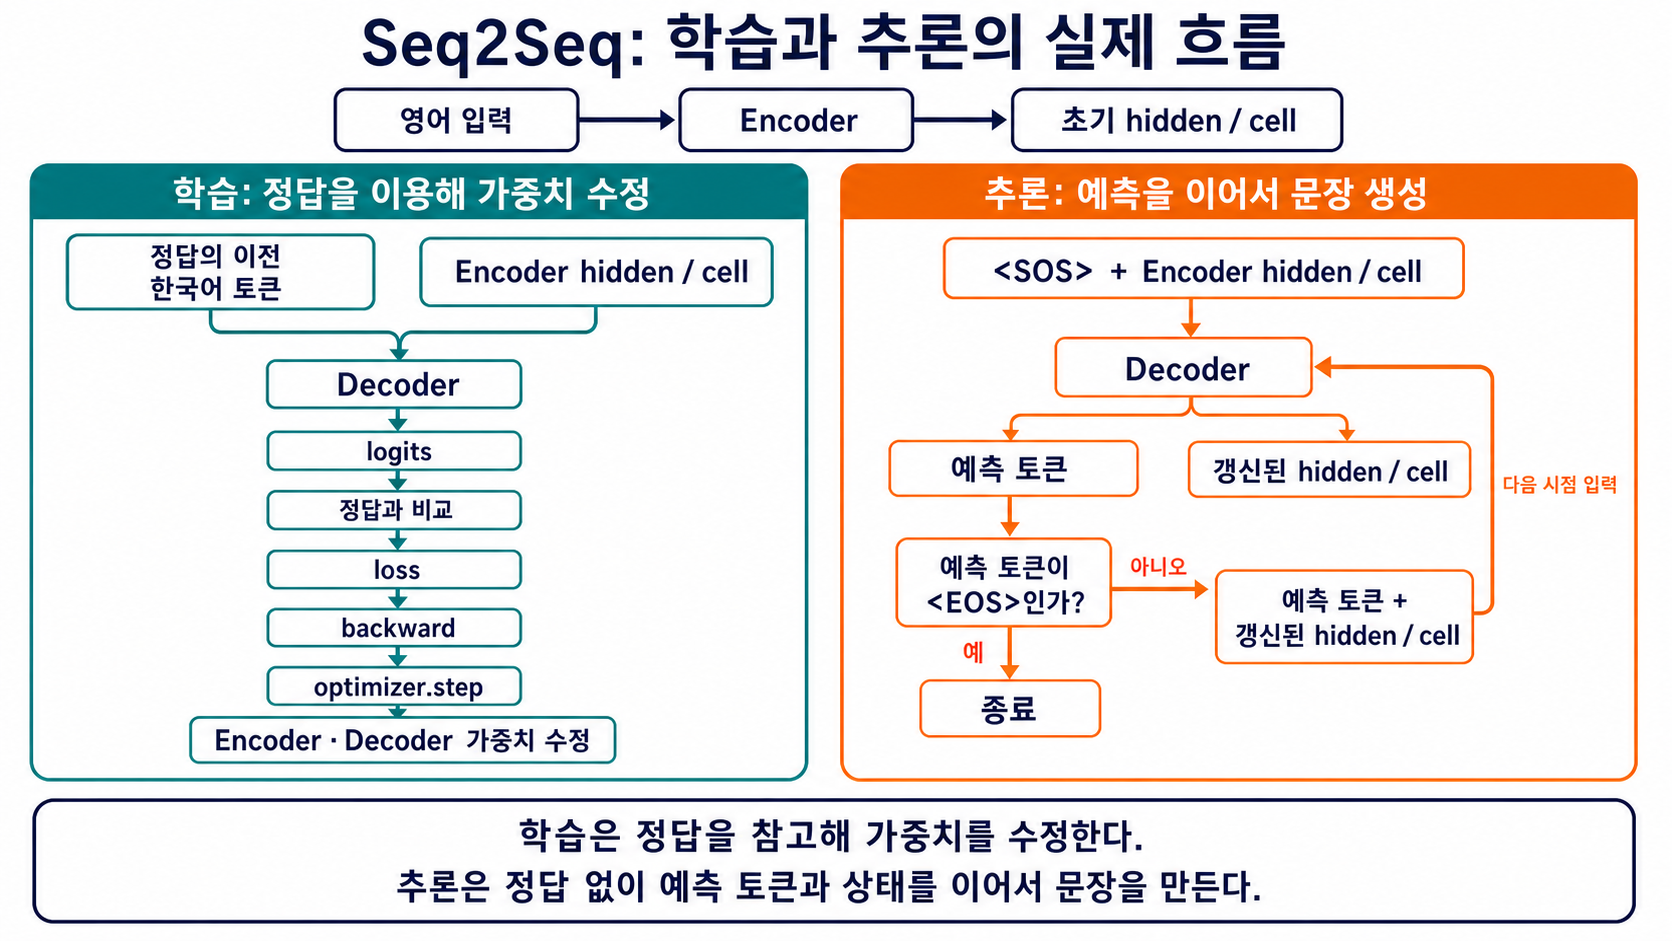
